In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score
)

In [4]:
df = pd.read_csv("../dataset/supply_chain_data.csv")

df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    str    
 1   SKU                      100 non-null    str    
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    str    
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    str    
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    str    
 14  Location                 100 non-null 

In [6]:
df.columns

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='str')

In [7]:
print(df.columns.tolist())

['Product type', 'SKU', 'Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Customer demographics', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Inspection results', 'Defect rates', 'Transportation modes', 'Routes', 'Costs']


In [8]:
df["Shipment_Delay"] = (df["Shipping times"] > 5).astype(int)

df[["Shipping times", "Shipment_Delay"]].head()

,Shipping times,Shipment_Delay
0,4,0
1,2,0
2,2,0
3,6,1
4,8,1


In [9]:
X = df.drop("Shipment_Delay", axis=1)
y = df["Shipment_Delay"]

print(X.shape)
print(y.shape)

(100, 24)
(100,)


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include="object").columns:
    X[col] = le.fit_transform(X[col])

C:\Users\shiva\AppData\Local\Temp\ipykernel_21260\3515072837.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include="object").columns:


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
import joblib

model = joblib.load("/shipment_delay_model.pkl")

print("Model loaded successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '/shipment_delay_model.pkl'

In [14]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if file.endswith(".pkl"):
            print(os.path.join(root, file))

..\notebooks\shipment_delay_model.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py27_np17.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py33_np18.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py34_np19.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py35_np19.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.11.0_pickle_py36_np111.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py27_np16.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py27_np17.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py33_np18.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py34_np19.pkl
..\venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py35_np19.pkl
..\venv\Lib\site-packages\numpy\_core\tests\data\astype_copy.pkl


In [15]:
import joblib

model = joblib.load("../notebooks/shipment_delay_model.pkl")

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [16]:
print(X_test.shape)

(20, 24)


In [17]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[1 0 0 1 1 0 1 0 0 0 1 1 0 1 1 1 1 0 0 0]


In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


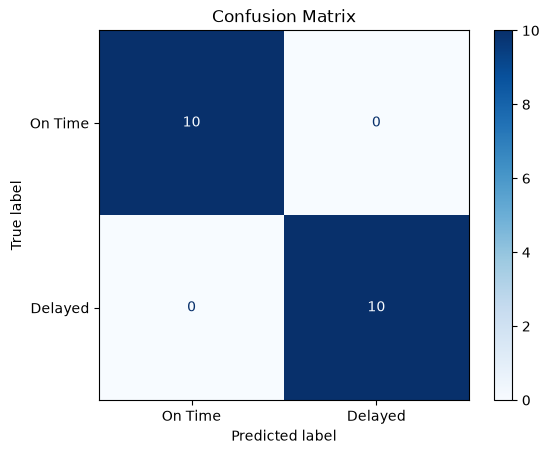

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["On Time", "Delayed"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [20]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [21]:
import pandas as pd

# Get feature importance values
importance = model.feature_importances_

# Create a DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 10 features
feature_importance.head(10)

,Feature,Importance
10,Shipping times,1.0
0,Product type,0.0
2,Price,0.0
1,SKU,0.0
4,Number of products sold,0.0
5,Revenue generated,0.0
6,Customer demographics,0.0
3,Availability,0.0
7,Stock levels,0.0
8,Lead times,0.0
